# transformer

--- 1. Début du Chargement du Domaine 2 ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé
Nombre total d'observations chargées : 79866


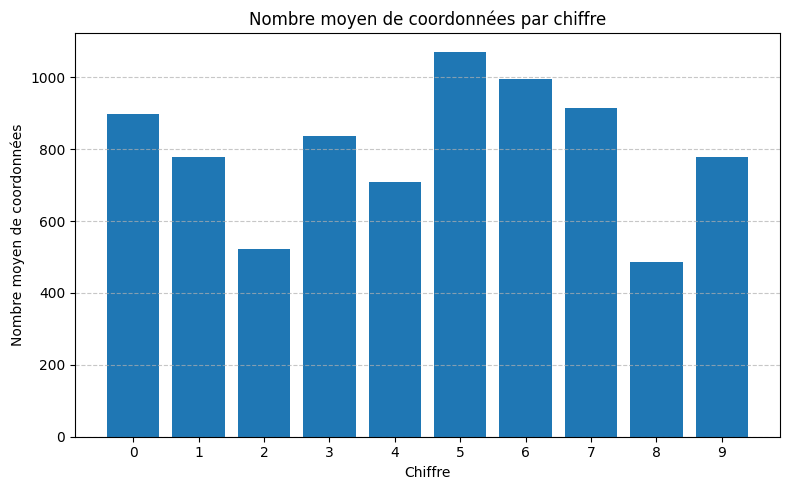

Chiffre 0 : 3980.00 s
Chiffre 1 : 3567.20 s
Chiffre 2 : 2570.50 s
Chiffre 3 : 4037.70 s
Chiffre 4 : 3087.10 s
Chiffre 5 : 5395.70 s
Chiffre 6 : 4499.00 s
Chiffre 7 : 4250.90 s
Chiffre 8 : 2463.70 s
Chiffre 9 : 3477.00 s


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_16848\2611384756.py:108: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



--- Test subject OUT : 1 ---

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 224ms/step - accuracy: 0.0967 - loss: 2.4345
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step - accuracy: 0.1989 - loss: 2.1510
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.7322 - loss: 0.7452
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.8500 - loss: 0.4441
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.9522 - loss: 0.1556
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 234ms/step - accuracy: 0.9644 - loss: 0.1257
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9856 - loss: 0.0668
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9833 - loss: 0.0431
Epoch 9/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.9911 - loss: 0.0314
Epoch 10/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.9667 - loss: 0.1039
Epoch 11/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.9722 - loss: 0.0852
Epoch 12/50
29/29 ━━

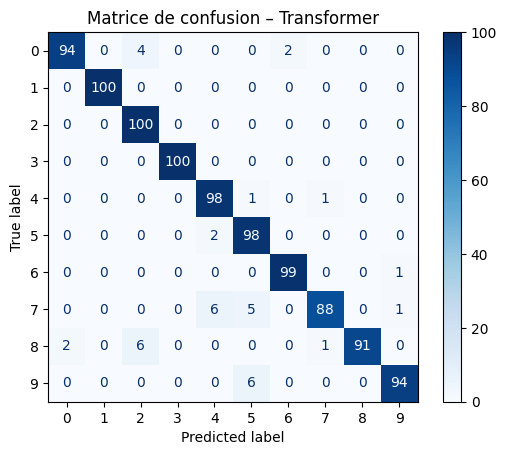

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2


df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2: continue


                data = file[0].str.strip('"').str.split(',', expand=True)

                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df_list.append(file_df)

            except FileNotFoundError:
                continue
            except Exception:
                continue


if not df_list:
    raise ValueError("Aucun fichier n'a pu être chargé. Vérifiez le chemin et le format des fichiers.")

df = pd.concat(df_list, ignore_index=True)

for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")


grouped = df.groupby(['gesture', 'iter'])
sequence_lengths = grouped.size().reset_index(name='length')
mean_lengths = sequence_lengths.groupby('gesture')['length'].mean().reset_index()
mean_lengths.columns = ['Chiffre', 'Frames moyennes']

plt.figure(figsize=(8, 5))
plt.bar(mean_lengths["Chiffre"], mean_lengths["Frames moyennes"])
plt.title("Nombre moyen de coordonnées par chiffre")
plt.xlabel("Chiffre")
plt.ylabel("Nombre moyen de coordonnées")
plt.xticks(mean_lengths["Chiffre"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
for gesture, mean_dur in mean_durations.items():
    print(f"Chiffre {gesture} : {mean_dur:.2f} s")




def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        if std == 0 or np.isnan(std):
            df_copy[f'{axis}_std'] = 0.0
        else:
            df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)




def resample_gesture(df_in, target_len=100):
    resampled_data = []

    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))

    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)




def create_user_independent_split(df_in, subj_out):
    train_df = df_in[df_in['subject'] != subj_out]
    test_df = df_in[df_in['subject'] == subj_out]

    def df_to_array(df_target):
        X, y = [], []
        for (gesture, subject, iteration), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(gesture)
        return np.array(X), np.array(y)

    X_train, y_train = df_to_array(train_df)
    X_test, y_test = df_to_array(test_df)
    return X_train, y_train, X_test, y_test




class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]




def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn = models.Sequential([
        layers.Dense(dff, activation="relu"),
        layers.Dense(d_model),
    ])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)
    return out2

def create_transformer_model(input_shape, num_classes, seq_len=100):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2

    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(seq_len, d_model)(x)

    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model




def test_transformer_user_independent(df_data, loop_range=10, epochs=50, batch_size=32, verbose_fit=1):
    total_true, total_pred = [], []

    for subj_out in range(1, loop_range + 1):
        if df_data[df_data['subject'] == subj_out].empty: continue

        print(f"\n--- Test subject OUT : {subj_out} ---")
        X_train, y_train, X_test, y_test = create_user_independent_split(df_data, subj_out)

        n_classes = len(np.unique(df_data['gesture']))
        input_shape = (X_train.shape[1], X_train.shape[2])

        model = create_transformer_model(input_shape=input_shape, num_classes=n_classes)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose_fit)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred)
        print(f"Exactitude subject {subj_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\nExactitude globale Transformer : {final_acc:.2%}")

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – Transformer")
    plt.show()


test_transformer_user_independent(df100, loop_range=10, epochs=50, batch_size=32, verbose_fit=1)

# edit distance dans cluster corssvalide

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17552\221923040.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 79866
Standardisation des données...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_17552\221923040.py:73: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)


Resampling à 100 points...
Test sur sujet sorti : 1
Précision split : 99.00%
Test sur sujet sorti : 2
Précision split : 88.00%
Test sur sujet sorti : 3
Précision split : 95.00%
Test sur sujet sorti : 4
Précision split : 96.00%
Test sur sujet sorti : 5
Précision split : 87.00%
Test sur sujet sorti : 6
Précision split : 93.00%
Test sur sujet sorti : 7
Précision split : 92.00%
Test sur sujet sorti : 8
Précision split : 80.00%
Test sur sujet sorti : 9
Précision split : 98.00%
Test sur sujet sorti : 10
Précision split : 96.00%

=== EXACTITUDE GLOBALE : 92.40% ===


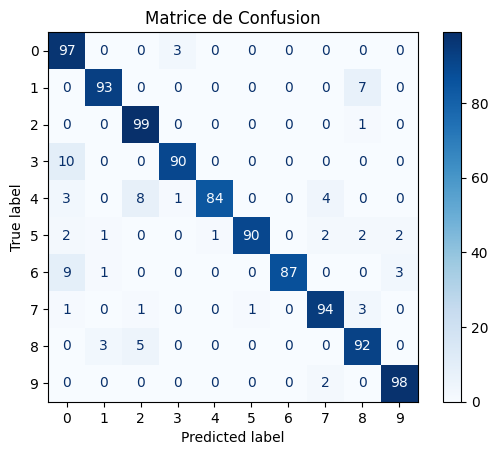

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue

print(f"Nombre total d'observations chargées : {len(df)}")


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = res[axis].std()
        res[f"{axis}_std"] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation des données...")
df = df.groupby(["subject", "gesture", "iter"], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    groups = df_input.groupby(["gesture", "subject", "iter"])

    for (gesture, subject, iteration), group in groups:
        n = len(group)
        if n < 2: continue

        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)

        res_dict = {
            "gesture": [gesture]*target_len,
            "subject": [subject]*target_len,
            "iter": [iteration]*target_len
        }

        for col in ["x_std", "y_std", "z_std"]:
            res_dict[col] = interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame(res_dict))

    return pd.concat(resampled_data, ignore_index=True)

print("Resampling à 100 points...")
df100 = resample_gesture(df)



def edit_distance(s1, s2):
    n, m = len(s1), len(s2)
    M = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): M[i][0] = i
    for j in range(m+1): M[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            M[i][j] = min(M[i-1][j] + 1, M[i][j-1] + 1, M[i-1][j-1] + cost)
    return M[n][m]

def gesture_to_sequence(df_sym):
    seq_dict = defaultdict(list)
    for (gesture, subject, iteration), group in df_sym.groupby(["gesture", "subject", "iter"]):
        seq = "".join(group["symbol"].tolist())
        seq_dict[gesture].append(seq)
    return seq_dict

def cluster_and_convert(df_train, df_test, k_clusters=50):
    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def assign_symbols(df_local):
        pts = df_local[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)
        symbols = [chr(ord('A') + (c % 26)) for c in clusters]
        df_copy = df_local.copy()
        df_copy["symbol"] = symbols
        return df_copy

    return gesture_to_sequence(assign_symbols(df_train)), gesture_to_sequence(assign_symbols(df_test))

def knn_edit_predict(seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = edit_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df_in, subj_out):
    return df_in[df_in["subject"] != subj_out], df_in[df_in["subject"] == subj_out]

def testmodel(df_target, loop_range=10, k_knn=7, k_clusters=50):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):
        print(f"Test sur sujet sorti : {i}")
        train_df, test_df = dict_creation_userout(df_target, i)

        if test_df.empty: continue

        train_seq, test_seq = cluster_and_convert(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_seq.items():
            for seq in sequences:
                pred = knn_edit_predict(seq, train_seq, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        total_true.extend(y_true)
        total_pred.extend(y_pred)
        print(f"Précision split : {accuracy_score(y_true, y_pred):.2%}")


    print(f"\n=== EXACTITUDE GLOBALE : {accuracy_score(total_true, total_pred):.2%} ===")
    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de Confusion")
    plt.show()

testmodel(df100)

# lcss knn 3 cluster 20 cluster dedans

--- Début du Chargement ---
Dossier source : \\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_12812\2244727691.py:48: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, file_df], ignore_index=True)


Nombre total d'observations chargées : 79866
Standardisation en cours...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_12812\2244727691.py:74: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling en cours...

--- TEST SUJET SORTI : 1 ---
Précision sujet 1 : 98.00%

--- TEST SUJET SORTI : 2 ---
Précision sujet 2 : 93.00%

--- TEST SUJET SORTI : 3 ---
Précision sujet 3 : 95.00%

--- TEST SUJET SORTI : 4 ---
Précision sujet 4 : 97.00%

--- TEST SUJET SORTI : 5 ---
Précision sujet 5 : 83.00%

--- TEST SUJET SORTI : 6 ---
Précision sujet 6 : 76.00%

--- TEST SUJET SORTI : 7 ---
Précision sujet 7 : 89.00%

--- TEST SUJET SORTI : 8 ---
Précision sujet 8 : 81.00%

--- TEST SUJET SORTI : 9 ---
Précision sujet 9 : 91.00%

--- TEST SUJET SORTI : 10 ---
Précision sujet 10 : 91.00%

=== EXACTITUDE GLOBALE KNN-LCSS : 89.40% ===


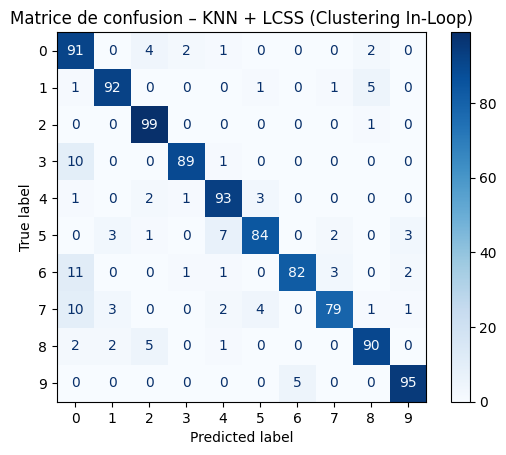

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d




DOMAIN_FOLDER = r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df = pd.DataFrame(columns=['x', 'y', 'z', 't', 'gesture', 'subject', 'iter'])

print(f"--- Début du Chargement ---")
print(f"Dossier source : {DOMAIN_FOLDER}")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration

                df = pd.concat([df, file_df], ignore_index=True)

            except FileNotFoundError:
                continue
            except Exception:
                continue


for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f"Nombre total d'observations chargées : {len(df)}")



def standardize_gesture(df_group):
    res = df_group.copy()
    for axis in ['x', 'y', 'z']:

        std = res[axis].std()
        res[f'{axis}_std'] = (res[axis] - res[axis].mean()) / std if std != 0 else 0
    return res

print("Standardisation en cours...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_input, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_input.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)

        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len,
            'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'),
            'y_std': interp('y_std'),
            'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling en cours...")
df100 = resample_gesture(df)



def cluster_and_symbolize(train_df, test_df, k_clusters=20):

    kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
    train_points = train_df[['x_std', 'y_std', 'z_std']].values
    kmeans.fit(train_points)

    def to_seq_dict(df_target):
        pts = df_target[['x_std', 'y_std', 'z_std']].values
        clusters = kmeans.predict(pts)

        symbols = [chr(ord('A') + (c % 26)) for c in clusters]

        temp_df = df_target.copy()
        temp_df['symbol'] = symbols

        seq_dict = defaultdict(list)
        for (gest, subj, it), group in temp_df.groupby(['gesture', 'subject', 'iter']):
            seq_dict[gest].append("".join(group['symbol'].tolist()))
        return seq_dict

    return to_seq_dict(train_df), to_seq_dict(test_df)



def lcs_length(s1, s2):
    n, m = len(s1), len(s2)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def lcs_distance(s1, s2):

    return len(s1) + len(s2) - 2 * lcs_length(s1, s2)

def knn_lcs_predict(seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for s in sequences:
            d = lcs_distance(seq, s)
            distances.append((gesture, d))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def testmodel(df_input, loop_range=10, k_knn=3, k_clusters=20):
    total_true, total_pred = [], []

    for i in range(1, loop_range + 1):

        train_df = df_input[df_input["subject"] != i]
        test_df = df_input[df_input["subject"] == i]

        if test_df.empty:
            continue

        print(f"\n--- TEST SUJET SORTI : {i} ---")


        train_dict, test_dict = cluster_and_symbolize(train_df, test_df, k_clusters)

        y_true, y_pred = [], []
        for gesture, sequences in test_dict.items():
            for seq in sequences:
                pred = knn_lcs_predict(seq, train_dict, k=k_knn)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        print(f"Précision sujet {i} : {acc:.2%}")
        total_true.extend(y_true)
        total_pred.extend(y_pred)

    final_acc = accuracy_score(total_true, total_pred)
    print(f"\n=== EXACTITUDE GLOBALE KNN-LCSS : {final_acc:.2%} ===")


    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title("Matrice de confusion – KNN + LCSS (Clustering In-Loop)")
    plt.show()


testmodel(df100)

#installe matplotlib

In [ ]:
import sys
!"{sys.executable}" -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


#dtw

--- Début du Chargement ---
✅ Données chargées : 79866 lignes.


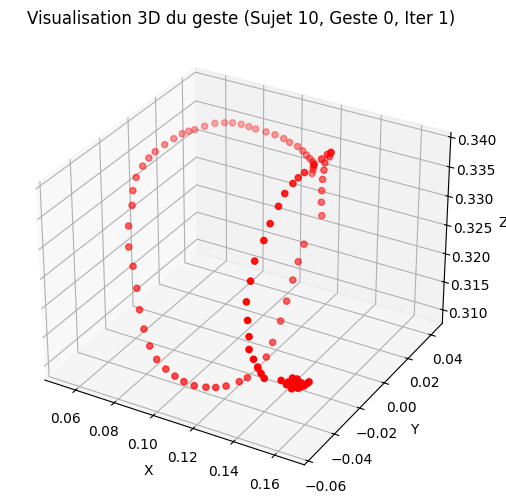


--- Durée moyenne des gestes (s) ---
gesture
0    3980.0
1    3567.2
2    2570.5
3    4037.7
4    3087.1
5    5395.7
6    4499.0
7    4250.9
8    2463.7
9    3477.0
Name: duration, dtype: float64


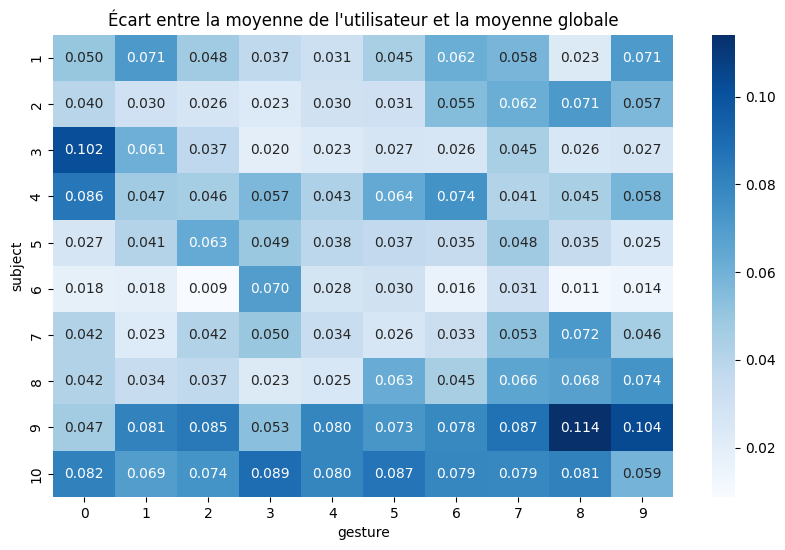

Standardisation...


C:\Users\Isadiki\AppData\Local\Temp\ipykernel_18484\2285233954.py:112: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling...

--- Test Split OUT : 1 ---
Précision split 1 : 100.00%

--- Test Split OUT : 2 ---
Précision split 2 : 97.00%

--- Test Split OUT : 3 ---
Précision split 3 : 94.00%

--- Test Split OUT : 4 ---
Précision split 4 : 100.00%

--- Test Split OUT : 5 ---
Précision split 5 : 97.00%

--- Test Split OUT : 6 ---
Précision split 6 : 97.00%

--- Test Split OUT : 7 ---
Précision split 7 : 98.00%

--- Test Split OUT : 8 ---
Précision split 8 : 96.00%

--- Test Split OUT : 9 ---
Précision split 9 : 98.00%

--- Test Split OUT : 10 ---
Précision split 10 : 98.00%

✅ Précision GLOBALE : 97.50%


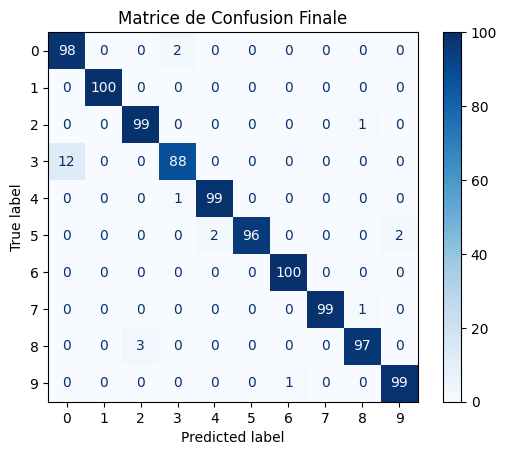

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import interp1d
import seaborn as sns



DOMAIN_FOLDER =r"\\student.fucam.ac.be\users$\isadiki\Downloads\Domain2base\DOMAIN2_CSVcorrigé"

df_list = []

print("--- Début du Chargement ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')

            try:

                file = pd.read_csv(filename, skiprows=5, header=None)

                if file.empty or file.shape[0] < 2:
                    continue


                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])


                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)


                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)

                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(" Aucun fichier chargé. Vérifiez le chemin : " + DOMAIN_FOLDER)

df = pd.concat(df_list, ignore_index=True)
for col in ['gesture', 'subject', 'iter']:
    df[col] = df[col].astype(int)

print(f" Données chargées : {len(df)} lignes.")



subdf = df.loc[(df['gesture'] == 0) & (df['subject'] == 10) & (df['iter'] == 1)]

if not subdf.empty:
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(subdf['x'], subdf['y'], subdf['z'], c='red', s=20)
    ax.set_title("Visualisation 3D du geste (Sujet 10, Geste 0, Iter 1)")
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    plt.show()




durations = df.groupby(['gesture', 'iter'])['t'].agg(lambda x: x.max() - x.min()).reset_index(name='duration')
mean_durations = durations.groupby('gesture')['duration'].mean()
print("\n--- Durée moyenne des gestes (s) ---")
print(mean_durations)


mean_coords_user = df.groupby(['subject', 'gesture'])[['x', 'y', 'z']].mean().reset_index()
mean_coords_global = df.groupby('gesture')[['x', 'y', 'z']].mean().reset_index().rename(
    columns={'x':'x_global', 'y':'y_global', 'z':'z_global'})

merged = pd.merge(mean_coords_user, mean_coords_global, on='gesture')
merged['dist_to_global'] = np.sqrt((merged['x']-merged['x_global'])**2 +
                                   (merged['y']-merged['y_global'])**2 +
                                   (merged['z']-merged['z_global'])**2)

pivot = merged.pivot(index='subject', columns='gesture', values='dist_to_global')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap='Blues')
plt.title("Écart entre la moyenne de l'utilisateur et la moyenne globale")
plt.show()



def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling...")
df100 = resample_gesture(df)



def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    k_nearest = distances[:k]
    votes = Counter([g for g, _ in k_nearest])
    return votes.most_common(1)[0][0]



def dict_creation_userout(df, subj_out):
    test_df = df[df["subject"] == subj_out]
    train_df = df[df["subject"] != subj_out]

    dict_train = defaultdict(list)
    dict_test = defaultdict(list)

    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    for (g, s, it), group in test_df.groupby(["gesture", "subject", "iter"]):
        dict_test[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())
    return dict_train, dict_test

def testmodel(DictCreationFunc, df, loop_range=10, k=3):
    total_true, total_pred = [], []
    for i in range(1, loop_range + 1):
        print(f"\n--- Test Split OUT : {i} ---")
        coord_train, coord_test = DictCreationFunc(df, i)
        y_true, y_pred = [], []
        for gesture, sequences in coord_test.items():
            for seq in sequences:
                pred = knn_dtw_predict(seq, coord_train, k=k)
                y_true.append(gesture)
                y_pred.append(pred)

        acc = accuracy_score(y_true, y_pred)
        total_true.extend(y_true); total_pred.extend(y_pred)
        print(f"Précision split {i} : {acc:.2%}")

    print(f"\nPrécision GLOBALE : {accuracy_score(total_true, total_pred):.2%}")
    cm = confusion_matrix(total_true, total_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title("Matrice de Confusion Finale")
    plt.show()


testmodel(dict_creation_userout, df100, loop_range=10, k=3)

# lstm 64 64 32 test 5 train 4


In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_2669/3725169490.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 16s 307ms/step - accuracy: 0.1512 - loss: 2.2308 - val_accuracy: 0.0000e+00 - val_loss: 2.7789
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.3611 - loss: 2.0024 - val_accuracy: 0.0000e+00 - val_loss: 3.5565
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - accuracy: 0.4414 - loss: 1.6618 - val_accuracy: 0.0000e+00 - val_loss: 4.2410
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.5031 - loss: 1.3342 - val_accuracy: 0.0000e+00 - val_loss: 4.0766
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - accuracy: 0.6728 - loss: 0.9726 - val_accuracy: 0.0000e+00 - val_loss: 4.7924
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 158ms/step - accuracy: 0.7037 - loss: 0.8189 - val_accuracy: 0.0000e+00 - val_loss: 4.3716
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.7284 - loss: 0.7206 - val_accuracy: 0.0000e+00 - val_loss: 4.8043
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - accuracy: 0.7963 - lo

# lstm 64 64 32 train 5V test 4


In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(64),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_2669/2851033601.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.2000 - loss: 2.2015 - val_accuracy: 0.0000e+00 - val_loss: 2.9486
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.4049 - loss: 1.8874 - val_accuracy: 0.0000e+00 - val_loss: 3.6981
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.5827 - loss: 1.3631 - val_accuracy: 0.0000e+00 - val_loss: 4.6376
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7951 - loss: 0.7889 - val_accuracy: 0.0000e+00 - val_loss: 5.0431
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.9012 - loss: 0.4509 - val_accuracy: 0.0000e+00 - val_loss: 5.3835
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9333 - loss: 0.2775 - val_accuracy: 0.0000e+00 - val_loss: 4.3891
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9556 - loss: 0.1804 - val_accuracy: 0.0000e+00 - val_loss: 3.2552
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.9580 - loss: 0.1428 - val_ac

# lstm 128 64 32 traéin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_2669/2428728044.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.2407 - loss: 2.1225 - val_accuracy: 0.0000e+00 - val_loss: 3.6349
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 0.4691 - loss: 1.5507 - val_accuracy: 0.0000e+00 - val_loss: 4.5242
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 277ms/step - accuracy: 0.6481 - loss: 1.0519 - val_accuracy: 0.0000e+00 - val_loss: 4.8392
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 240ms/step - accuracy: 0.7438 - loss: 0.7342 - val_accuracy: 0.0000e+00 - val_loss: 5.0344
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 245ms/step - accuracy: 0.7901 - loss: 0.6142 - val_accuracy: 0.0000e+00 - val_loss: 5.2485
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 442ms/step - accuracy: 0.8179 - loss: 0.5717 - val_accuracy: 0.0000e+00 - val_loss: 4.7091
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 245ms/step - accuracy: 0.8580 - loss: 0.4589 - val_accuracy: 0.0000e+00 - val_loss: 4.8264
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 233ms/step - accuracy: 0.8981 - loss: 0.2883 -

# lstm 128 32 32 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(128),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_2669/3874514207.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 314ms/step - accuracy: 0.2914 - loss: 2.0116 - val_accuracy: 0.0000e+00 - val_loss: 4.1779
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 302ms/step - accuracy: 0.6741 - loss: 1.1013 - val_accuracy: 0.0000e+00 - val_loss: 4.7128
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 292ms/step - accuracy: 0.8494 - loss: 0.5240 - val_accuracy: 0.0000e+00 - val_loss: 3.7741
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 322ms/step - accuracy: 0.9259 - loss: 0.2731 - val_accuracy: 0.0000e+00 - val_loss: 2.9751
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.9407 - loss: 0.2097 - val_accuracy: 0.2000 - val_loss: 2.5420
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 0.9852 - loss: 0.0990 - val_accuracy: 0.3111 - val_loss: 3.0711
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - accuracy: 0.9753 - loss: 0.0979 - val_accuracy: 0.2667 - val_loss: 2.2855
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 375ms/step - accuracy: 0.9284 - loss: 0.2120 - val_accurac

# lstm 256 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 4
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_2669/1955807867.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1975 - loss: 2.0621 - val_accuracy: 0.0000e+00 - val_loss: 3.6985
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.4877 - loss: 1.3918 - val_accuracy: 0.0000e+00 - val_loss: 4.5816
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6296 - loss: 0.9466 - val_accuracy: 0.0000e+00 - val_loss: 4.7215
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.6543 - loss: 0.8848 - val_accuracy: 0.0000e+00 - val_loss: 3.3351
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 730ms/step - accuracy: 0.7006 - loss: 0.7510 - val_accuracy: 0.0000e+00 - val_loss: 4.3285
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 864ms/step - accuracy: 0.8333 - loss: 0.5120 - val_accuracy: 0.0000e+00 - val_loss: 3.7827
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 966ms/step - accuracy: 0.9167 - loss: 0.2963 - val_accuracy: 0.0000e+00 - val_loss: 4.2523
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 696ms/step - accuracy: 0.9198 - loss: 0.26

# lstm 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 4
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS =   [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

# --- 4. Modèle ---
def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 4 ---


/tmp/ipykernel_2669/2491580262.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 845ms/step - accuracy: 0.2914 - loss: 1.9039 - val_accuracy: 0.0000e+00 - val_loss: 4.7090
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 877ms/step - accuracy: 0.6617 - loss: 0.9493 - val_accuracy: 0.0000e+00 - val_loss: 4.4083
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 715ms/step - accuracy: 0.8395 - loss: 0.4477 - val_accuracy: 0.0667 - val_loss: 2.3772
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 787ms/step - accuracy: 0.8790 - loss: 0.3436 - val_accuracy: 0.0000e+00 - val_loss: 2.4812
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 858ms/step - accuracy: 0.9432 - loss: 0.2309 - val_accuracy: 0.0222 - val_loss: 3.0361
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 803ms/step - accuracy: 0.9160 - loss: 0.2498 - val_accuracy: 0.5556 - val_loss: 1.8773
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 770ms/step - accuracy: 0.9259 - loss: 0.2485 - val_accuracy: 0.1778 - val_loss: 2.5022
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 783ms/step - accuracy: 0.9457 - loss: 0.222

# lstm 256 64 32 test syr sujet 3

In [4]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS = [1, 2, 4, 5, 6, 7, 8, 9, 10]
TEST_SUBJECTS =  [3]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_885/1593295802.py:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 722ms/step - accuracy: 0.3896 - loss: 1.7077 - val_accuracy: 0.0000e+00 - val_loss: 5.1998
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 656ms/step - accuracy: 0.6804 - loss: 0.8598 - val_accuracy: 0.0000e+00 - val_loss: 3.3172
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 652ms/step - accuracy: 0.8217 - loss: 0.4694 - val_accuracy: 0.0123 - val_loss: 3.8682
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 663ms/step - accuracy: 0.8642 - loss: 0.4009 - val_accuracy: 0.2099 - val_loss: 2.7466
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 684ms/step - accuracy: 0.9369 - loss: 0.2391 - val_accuracy: 0.1728 - val_loss: 1.8782
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 653ms/step - accuracy: 0.9492 - loss: 0.1839 - val_accuracy: 0.0000e+00 - val_loss: 6.3928
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 674ms/step - accuracy: 0.9465 - loss: 0.1691 - val_accuracy: 0.0123 - val_loss: 4.8245
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 24s 854ms/step - accuracy: 0.9383 - loss: 0.2482 - val_acc

# lstm 256 dense 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

# --- CONFIGURATION ---
DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)


def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/4291959562.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 672ms/step - accuracy: 0.2191 - loss: 2.1642 - val_accuracy: 0.0000e+00 - val_loss: 3.6556
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 659ms/step - accuracy: 0.4167 - loss: 1.7496 - val_accuracy: 0.0000e+00 - val_loss: 3.8293
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 740ms/step - accuracy: 0.5154 - loss: 1.3747 - val_accuracy: 0.0000e+00 - val_loss: 3.2157
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 657ms/step - accuracy: 0.7130 - loss: 0.9083 - val_accuracy: 0.0000e+00 - val_loss: 4.8563
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 661ms/step - accuracy: 0.7870 - loss: 0.7327 - val_accuracy: 0.0000e+00 - val_loss: 3.7448
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 748ms/step - accuracy: 0.7377 - loss: 0.9029 - val_accuracy: 0.0000e+00 - val_loss: 3.3419
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 614ms/step - accuracy: 0.7963 - loss: 0.6117 - val_accuracy: 0.0000e+00 - val_loss: 4.9562
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 628ms/step - accuracy: 0.8241 - loss: 0.63

# lstm 256 dense 32 32 trin 5 test *4*

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS =  [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/1732586559.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 795ms/step - accuracy: 0.3235 - loss: 1.9326 - val_accuracy: 0.0000e+00 - val_loss: 4.1331
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 715ms/step - accuracy: 0.6321 - loss: 1.0398 - val_accuracy: 0.0000e+00 - val_loss: 4.5345
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 641ms/step - accuracy: 0.8593 - loss: 0.5563 - val_accuracy: 0.0000e+00 - val_loss: 5.8865
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 744ms/step - accuracy: 0.8765 - loss: 0.4421 - val_accuracy: 0.0000e+00 - val_loss: 3.6859
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 742ms/step - accuracy: 0.8519 - loss: 0.4631 - val_accuracy: 0.0000e+00 - val_loss: 4.7144
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 641ms/step - accuracy: 0.8568 - loss: 0.4600 - val_accuracy: 0.0000e+00 - val_loss: 3.7569
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 733ms/step - accuracy: 0.9506 - loss: 0.2267 - val_accuracy: 0.0000e+00 - val_loss: 3.8093
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 739ms/step - accuracy: 0.9037 - loss: 0.31

# lstm 256 dense 16 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/4255139454.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 807ms/step - accuracy: 0.1944 - loss: 2.1230 - val_accuracy: 0.0000e+00 - val_loss: 3.6011
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 654ms/step - accuracy: 0.3117 - loss: 1.7910 - val_accuracy: 0.0000e+00 - val_loss: 4.0429
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 766ms/step - accuracy: 0.4599 - loss: 1.4316 - val_accuracy: 0.0000e+00 - val_loss: 4.7599
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 676ms/step - accuracy: 0.5062 - loss: 1.1637 - val_accuracy: 0.0000e+00 - val_loss: 4.0028
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 635ms/step - accuracy: 0.5926 - loss: 1.1056 - val_accuracy: 0.0000e+00 - val_loss: 5.2221
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 780ms/step - accuracy: 0.6759 - loss: 0.8760 - val_accuracy: 0.0000e+00 - val_loss: 6.1731
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 841ms/step - accuracy: 0.6728 - loss: 0.8603 - val_accuracy: 0.0000e+00 - val_loss: 4.8750
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 665ms/step - accuracy: 0.7531 - loss: 0.7217

# lstm 256 densde 16 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =    [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/3480917828.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 684ms/step - accuracy: 0.1951 - loss: 2.1122 - val_accuracy: 0.0000e+00 - val_loss: 2.8217
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 747ms/step - accuracy: 0.4519 - loss: 1.5456 - val_accuracy: 0.0000e+00 - val_loss: 2.8437
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 753ms/step - accuracy: 0.5975 - loss: 1.0634 - val_accuracy: 0.0222 - val_loss: 2.8907
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 750ms/step - accuracy: 0.7012 - loss: 0.8457 - val_accuracy: 0.0444 - val_loss: 3.5849
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 649ms/step - accuracy: 0.7457 - loss: 0.7491 - val_accuracy: 0.0000e+00 - val_loss: 2.7903
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 753ms/step - accuracy: 0.8222 - loss: 0.5896 - val_accuracy: 0.0000e+00 - val_loss: 2.2824
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 750ms/step - accuracy: 0.8691 - loss: 0.5025 - val_accuracy: 0.0444 - val_loss: 2.2277
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 740ms/step - accuracy: 0.9012 - loss: 0.3510 - val_

# lstm 256 64 batch size 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/3706310312.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1512 - loss: 2.1763 - val_accuracy: 0.0000e+00 - val_loss: 3.2073
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 889ms/step - accuracy: 0.3302 - loss: 1.7499 - val_accuracy: 0.0000e+00 - val_loss: 3.9758
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 862ms/step - accuracy: 0.5278 - loss: 1.3112 - val_accuracy: 0.0000e+00 - val_loss: 4.2204
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 867ms/step - accuracy: 0.6481 - loss: 0.9947 - val_accuracy: 0.0000e+00 - val_loss: 3.6463
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7593 - loss: 0.7716 - val_accuracy: 0.0000e+00 - val_loss: 4.5973
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7593 - loss: 0.7077 - val_accuracy: 0.0000e+00 - val_loss: 4.4060
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 844ms/step - accuracy: 0.8086 - loss: 0.5205 - val_accuracy: 0.0000e+00 - val_loss: 4.8653
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7994 - loss: 0.5937 - val_accuracy: 0.0000e+00

# lstm 256 64 64 tain 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers


if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =    [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/3914028705.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2691 - loss: 2.0687 - val_accuracy: 0.0000e+00 - val_loss: 4.3449
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 987ms/step - accuracy: 0.5654 - loss: 1.2540 - val_accuracy: 0.0000e+00 - val_loss: 4.4741
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7481 - loss: 0.7275 - val_accuracy: 0.0000e+00 - val_loss: 4.7252
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 912ms/step - accuracy: 0.8519 - loss: 0.4429 - val_accuracy: 0.0000e+00 - val_loss: 4.2743
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8840 - loss: 0.3684 - val_accuracy: 0.0222 - val_loss: 2.6503
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 919ms/step - accuracy: 0.9358 - loss: 0.2657 - val_accuracy: 0.0667 - val_loss: 2.8975
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 895ms/step - accuracy: 0.9185 - loss: 0.2545 - val_accuracy: 0.3111 - val_loss: 2.4653
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8765 - loss: 0.3330 - val_accuracy: 0.1333 - val

# lstm 256 64 batch size 16 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =  [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/2404492133.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 483ms/step - accuracy: 0.2963 - loss: 1.8850 - val_accuracy: 0.0000e+00 - val_loss: 4.1617
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 526ms/step - accuracy: 0.5247 - loss: 1.1137 - val_accuracy: 0.0000e+00 - val_loss: 4.1102
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 530ms/step - accuracy: 0.6358 - loss: 1.0048 - val_accuracy: 0.0000e+00 - val_loss: 3.9867
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 529ms/step - accuracy: 0.6821 - loss: 0.7773 - val_accuracy: 0.0000e+00 - val_loss: 3.8876
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 516ms/step - accuracy: 0.6636 - loss: 0.8042 - val_accuracy: 0.0000e+00 - val_loss: 4.9361
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 468ms/step - accuracy: 0.7623 - loss: 0.6726 - val_accuracy: 0.0000e+00 - val_loss: 3.5310
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 527ms/step - accuracy: 0.8426 - loss: 0.5282 - val_accuracy: 0.0000e+00 - val_loss: 7.1759
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 21s 532ms/step - accuracy: 0.8735 - loss: 

# lstm 256 32 16 trian 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import models, layers

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2
TRAIN_SUBJECTS =   [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError(f"Aucun fichier chargé.")

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len, 'x_std': interp('x_std'),
            'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

def create_lstm_model(input_shape, num_classes):
    model = models.Sequential([
        layers.LSTM(256, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.2),
        layers.LSTM(256),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
         layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_lstm_model((X_train.shape[1], X_train.shape[2]), 10)
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print(f"\n" + "="*40)
print(f"CONFIGURATION DU TEST")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets        : {TEST_SUBJECTS}")
print("="*40)

print(f"\n--- RÉSULTATS DÉTAILLÉS ---")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

subject_scores = {}
for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Précision Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TEST : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 ---


/tmp/ipykernel_834/2653764742.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 19s 530ms/step - accuracy: 0.4074 - loss: 1.6390 - val_accuracy: 0.0000e+00 - val_loss: 5.2662
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 509ms/step - accuracy: 0.7407 - loss: 0.7718 - val_accuracy: 0.0000e+00 - val_loss: 5.4699
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 501ms/step - accuracy: 0.8395 - loss: 0.5199 - val_accuracy: 0.0000e+00 - val_loss: 4.8526
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 507ms/step - accuracy: 0.7506 - loss: 0.6855 - val_accuracy: 0.0000e+00 - val_loss: 2.8857
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 506ms/step - accuracy: 0.8914 - loss: 0.3181 - val_accuracy: 0.0000e+00 - val_loss: 3.5889
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 506ms/step - accuracy: 0.9358 - loss: 0.2499 - val_accuracy: 0.0000e+00 - val_loss: 1.8161
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 515ms/step - accuracy: 0.9531 - loss: 0.1626 - val_accuracy: 0.0000e+00 - val_loss: 2.6430
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 13s 509ms/step - accuracy: 0.8519 - loss: 

# transformer

# tranhsfo 64 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)



--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_834/3534499778.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.1265 - loss: 2.3349 - val_accuracy: 0.0000e+00 - val_loss: 3.5404
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 981ms/step - accuracy: 0.1111 - loss: 2.2574 - val_accuracy: 0.0000e+00 - val_loss: 4.6327
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 910ms/step - accuracy: 0.1235 - loss: 2.2217 - val_accuracy: 0.0000e+00 - val_loss: 3.9530
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 898ms/step - accuracy: 0.2778 - loss: 1.9458 - val_accuracy: 0.0000e+00 - val_loss: 4.8318
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5772 - loss: 1.1599 - val_accuracy: 0.0000e+00 - val_loss: 5.6279
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 987ms/step - accuracy: 0.8148 - loss: 0.5848 - val_accuracy: 0.0000e+00 - val_loss: 3.2558
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 989ms/step - accuracy: 0.9074 - loss: 0.3308 - val_accuracy: 0.2778 - val_loss: 2.5866
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s

# tranfo 64 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)

# --- 3. SÉPARATION TRAIN / TEST ---

def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 64, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_834/629249989.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.1111 - loss: 2.3657 - val_accuracy: 0.0000e+00 - val_loss: 4.4418
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.1407 - loss: 2.2215 - val_accuracy: 0.0000e+00 - val_loss: 4.1158
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1827 - loss: 2.0494 - val_accuracy: 0.0000e+00 - val_loss: 3.7220
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8025 - loss: 0.7216 - val_accuracy: 0.0444 - val_loss: 3.7859
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9259 - loss: 0.2157 - val_accuracy: 0.5556 - val_loss: 1.5862
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9728 - loss: 0.1044 - val_accuracy: 0.6000 - val_loss: 1.7629
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9852 - loss: 0.0517 - val_accuracy: 0.4889 - val_loss: 2.4387
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9926



# transo 256 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_49914/200719545.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1605 - loss: 2.3082 - val_accuracy: 0.0000e+00 - val_loss: 4.6330
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1111 - loss: 2.2222 - val_accuracy: 0.0000e+00 - val_loss: 3.8253
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1759 - loss: 2.1634 - val_accuracy: 0.0000e+00 - val_loss: 4.0488
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4630 - loss: 1.4413 - val_accuracy: 0.0000e+00 - val_loss: 4.4771
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.8179 - loss: 0.6574 - val_accuracy: 0.0000e+00 - val_loss: 4.9340
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8920 - loss: 0.4039 - val_accuracy: 0.0000e+00 - val_loss: 4.3859
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9568 - loss: 0.1645 - val_accuracy: 0.0000e+00 - val_loss: 2.6656
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - 

# tranqgfo 256 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_49914/3652900707.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.0864 - loss: 2.3726 - val_accuracy: 0.0000e+00 - val_loss: 3.7846
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.1111 - loss: 2.2007 - val_accuracy: 0.0000e+00 - val_loss: 4.4372
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2173 - loss: 2.0740 - val_accuracy: 0.0000e+00 - val_loss: 4.3662
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7037 - loss: 0.9366 - val_accuracy: 0.0000e+00 - val_loss: 4.3026
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9753 - loss: 0.1598 - val_accuracy: 0.3556 - val_loss: 2.4281
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9852 - loss: 0.0715 - val_accuracy: 0.4667 - val_loss: 2.4104
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9926 - loss: 0.0337 - val_accuracy: 0.4000 - val_loss: 2.2054
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 1.

# traqnfo 128 128 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_49914/3003228400.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1080 - loss: 2.4473 - val_accuracy: 0.0000e+00 - val_loss: 4.2095
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1142 - loss: 2.2318 - val_accuracy: 0.0000e+00 - val_loss: 3.9317
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.1235 - loss: 2.2034 - val_accuracy: 0.0000e+00 - val_loss: 4.0787
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1296 - loss: 2.2284 - val_accuracy: 0.0000e+00 - val_loss: 4.3505
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1636 - loss: 2.1650 - val_accuracy: 0.0000e+00 - val_loss: 3.4503
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4259 - loss: 1.6132 - val_accuracy: 0.0000e+00 - val_loss: 3.5835
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.6883 - loss: 0.9269 - val_accuracy: 0.0000e+00 - val_loss: 5.9484
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - 

# trasnfo 128 128 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 128, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_49914/2769295152.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.0963 - loss: 2.3437 - val_accuracy: 0.0000e+00 - val_loss: 4.0858
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1235 - loss: 2.2575 - val_accuracy: 0.0000e+00 - val_loss: 3.9606
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1111 - loss: 2.1727 - val_accuracy: 0.0000e+00 - val_loss: 3.6473
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1630 - loss: 2.0832 - val_accuracy: 0.0000e+00 - val_loss: 4.1751
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5630 - loss: 1.2368 - val_accuracy: 0.0000e+00 - val_loss: 5.2862
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.8469 - loss: 0.5202 - val_accuracy: 0.0000e+00 - val_loss: 5.5954
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9160 - loss: 0.2394 - val_accuracy: 0.1111 - val_loss: 3.2740
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accu

# trasnfo 256 128 32 tests ur sujet 3

In [6]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5, 6, 7, 8, 9, 10]
TEST_SUBJECTS = [3]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID}  ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2  ---


/tmp/ipykernel_885/1770268101.py:64: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.1509 - loss: 2.3447 - val_accuracy: 0.0000e+00 - val_loss: 4.3751
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.3374 - loss: 1.8013 - val_accuracy: 0.0000e+00 - val_loss: 4.1996
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8052 - loss: 0.5710 - val_accuracy: 0.0000e+00 - val_loss: 2.3785
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9465 - loss: 0.2058 - val_accuracy: 0.6420 - val_loss: 1.6265
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9561 - loss: 0.1393 - val_accuracy: 0.3580 - val_loss: 2.6420
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9643 - loss: 0.1008 - val_accuracy: 0.6790 - val_loss: 1.4160
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 981ms/step - accuracy: 0.9835 - loss: 0.0554 - val_accuracy: 0.5679 - val_loss: 2.9610
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9

# transofd 256 64 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")


def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_49914/1150629865.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1235 - loss: 2.4004 - val_accuracy: 0.0000e+00 - val_loss: 4.9715
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.1265 - loss: 2.3268 - val_accuracy: 0.0000e+00 - val_loss: 3.2796
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.1451 - loss: 2.2183 - val_accuracy: 0.0000e+00 - val_loss: 3.6115
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1019 - loss: 2.2084 - val_accuracy: 0.0000e+00 - val_loss: 3.6889
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.1204 - loss: 2.1602 - val_accuracy: 0.0000e+00 - val_loss: 4.0842
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3488 - loss: 1.7331 - val_accuracy: 0.0000e+00 - val_loss: 4.9479
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.5525 - loss: 1.1377 - val_accuracy: 0.0000e+00 - val_loss: 6.0569
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - 

# trnsof 256 64 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")


def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_49914/3249158527.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.1358 - loss: 2.3859 - val_accuracy: 0.0000e+00 - val_loss: 4.5909
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1457 - loss: 2.2198 - val_accuracy: 0.0000e+00 - val_loss: 4.4137
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.1383 - loss: 2.1540 - val_accuracy: 0.0000e+00 - val_loss: 4.7633
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.3259 - loss: 1.7247 - val_accuracy: 0.0000e+00 - val_loss: 5.7744
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7802 - loss: 0.7184 - val_accuracy: 0.1333 - val_loss: 3.0564
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9284 - loss: 0.2886 - val_accuracy: 0.3111 - val_loss: 3.2569
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9704 - loss: 0.1529 - val_accuracy: 0.5556 - val_loss: 2.4708
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.

# transfo 256 32 32 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")


def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_49914/842181402.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.0957 - loss: 2.4969 - val_accuracy: 0.0000e+00 - val_loss: 2.3065
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1204 - loss: 2.2979 - val_accuracy: 0.0000e+00 - val_loss: 2.6861
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1049 - loss: 2.3108 - val_accuracy: 0.0000e+00 - val_loss: 2.7775
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1204 - loss: 2.3072 - val_accuracy: 0.0000e+00 - val_loss: 2.2892
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1173 - loss: 2.2915 - val_accuracy: 0.0000e+00 - val_loss: 2.4281
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1327 - loss: 2.2875 - val_accuracy: 0.0000e+00 - val_loss: 2.6571
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1080 - loss: 2.2905 - val_accuracy: 0.0000e+00 - val_loss: 2.3791
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - 

# transfo 256 32 32 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_49914/2529965381.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.1185 - loss: 2.3537 - val_accuracy: 0.0000e+00 - val_loss: 2.6217
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1185 - loss: 2.2638 - val_accuracy: 0.0000e+00 - val_loss: 2.8154
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.1630 - loss: 2.2140 - val_accuracy: 0.0000e+00 - val_loss: 2.7390
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4765 - loss: 1.6623 - val_accuracy: 0.0000e+00 - val_loss: 3.7345
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6667 - loss: 1.0838 - val_accuracy: 0.0000e+00 - val_loss: 4.8343
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7975 - loss: 0.6471 - val_accuracy: 0.0000e+00 - val_loss: 5.5971
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.9037 - loss: 0.3934 - val_accuracy: 0.0000e+00 - val_loss: 6.0922
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - 

# transfo 256 128 bathc 16 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)
print(f"Nombre total d'observations chargées : {len(df)}")


def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

Décompression terminée !
--- 1. Début du Chargement du Domaine 2 (Transformer) ---
Nombre total d'observations chargées : 72077


/tmp/ipykernel_12855/1143469110.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 947ms/step - accuracy: 0.1420 - loss: 2.3301 - val_accuracy: 0.0000e+00 - val_loss: 2.9378
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 17s 822ms/step - accuracy: 0.1327 - loss: 2.2389 - val_accuracy: 0.0000e+00 - val_loss: 3.1975
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 582ms/step - accuracy: 0.1451 - loss: 2.2144 - val_accuracy: 0.0000e+00 - val_loss: 4.0441
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 644ms/step - accuracy: 0.2870 - loss: 1.8924 - val_accuracy: 0.0000e+00 - val_loss: 5.4161
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 20s 647ms/step - accuracy: 0.6265 - loss: 1.0098 - val_accuracy: 0.0000e+00 - val_loss: 4.2991
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 19s 583ms/step - accuracy: 0.7377 - loss: 0.7051 - val_accuracy: 0.0000e+00 - val_loss: 4.1155
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 12s 576ms/step - accuracy: 0.8580 - loss: 0.4903 - val_accuracy: 0.0000e+00 - val_loss: 3.2457
Epoch 8/50
21/21 ━━━━━━━━━━━━━━





# transfp 256 128 16 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)

class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_12855/3622359204.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 16s 425ms/step - accuracy: 0.1136 - loss: 2.3063 - val_accuracy: 0.0000e+00 - val_loss: 4.1448
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 405ms/step - accuracy: 0.2494 - loss: 2.0089 - val_accuracy: 0.0000e+00 - val_loss: 3.8021
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 396ms/step - accuracy: 0.7728 - loss: 0.6946 - val_accuracy: 0.0000e+00 - val_loss: 2.9406
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 21s 411ms/step - accuracy: 0.8469 - loss: 0.4217 - val_accuracy: 0.0000e+00 - val_loss: 4.8509
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 412ms/step - accuracy: 0.9333 - loss: 0.2144 - val_accuracy: 0.2667 - val_loss: 2.9651
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 406ms/step - accuracy: 0.9358 - loss: 0.1749 - val_accuracy: 0.4222 - val_loss: 2.6549
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 406ms/step - accuracy: 0.9704 - loss: 0.1142 - val_accuracy: 0.5111 - val_loss: 2.5407
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 4

# transfo 256 128 64 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_12855/2094451896.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.1142 - loss: 2.3929 - val_accuracy: 0.0000e+00 - val_loss: 3.5161
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1728 - loss: 2.3246 - val_accuracy: 0.0000e+00 - val_loss: 3.3324
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1142 - loss: 2.3547 - val_accuracy: 0.0000e+00 - val_loss: 3.2320
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1420 - loss: 2.2279 - val_accuracy: 0.0000e+00 - val_loss: 3.1961
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1265 - loss: 2.2041 - val_accuracy: 0.0000e+00 - val_loss: 3.5918
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1420 - loss: 2.2046 - val_accuracy: 0.0000e+00 - val_loss: 3.6580
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1265 - loss: 2.2153 - val_accuracy: 0.0000e+00 - val_loss: 3.6574
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1049 - los

# transfo 256 128 64 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tensorflow.keras import layers, models
import tensorflow as tf

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print("Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS =  [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []

print(f"--- 1. Début du Chargement du Domaine {DOMAIN_ID} (Transformer) ---")

for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)

                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

if not df_list:
    raise ValueError("Aucun fichier chargé. Vérifiez le chemin /content/temp_data/DOMAIN2_CSV")

df = pd.concat(df_list, ignore_index=True)



def standardize_gesture(df_group):
    df_copy = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_copy[axis].std()
        df_copy[f'{axis}_std'] = (df_copy[axis] - df_copy[axis].mean()) / std if std > 0 else 0.0
    return df_copy

df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df_in, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df_in.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col].values, kind='linear', fill_value="extrapolate")(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len,
            'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

df100 = resample_gesture(df)


def prepare_data_split(df_in, train_subs, test_subs):
    train_df = df_in[df_in['subject'].isin(train_subs)]
    test_df = df_in[df_in['subject'].isin(test_subs)]

    def df_to_array(df_target):
        X, y, sub_ids = [], [], []
        for (g, s, i), group in df_target.groupby(['gesture', 'subject', 'iter']):
            X.append(group[['x_std', 'y_std', 'z_std']].values)
            y.append(g)
            sub_ids.append(s)
        return np.array(X), np.array(y), np.array(sub_ids)

    X_train, y_train, _ = df_to_array(train_df)
    X_test, y_test, test_sub_ids = df_to_array(test_df)
    return X_train, y_train, X_test, y_test, test_sub_ids

X_train, y_train, X_test, y_test, test_sub_ids = prepare_data_split(df100, TRAIN_SUBJECTS, TEST_SUBJECTS)


class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
        self.positional_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.positional_encoding[:, :seq_len, :]

def transformer_encoder(x, num_heads, d_model, dff, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(x, x)
    attn_output = layers.Dropout(dropout)(attn_output)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = models.Sequential([layers.Dense(dff, activation="relu"), layers.Dense(d_model)])
    ffn_output = ffn(out1)
    ffn_output = layers.Dropout(dropout)(ffn_output)
    return layers.LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

def create_transformer_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    d_model, num_heads, num_layers, dff, dropout = 128, 8, 2, 256, 0.2
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(100, d_model)(x)
    for _ in range(num_layers):
        x = transformer_encoder(x, num_heads, d_model, dff, dropout)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = create_transformer_model((X_train.shape[1], X_train.shape[2]), 10)
print("\nEntraînement Transformer en cours...")
model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.1, verbose=1)

print("\n" + "="*40)
print(f"RÉSULTATS DÉTAILLÉS - TRANSFORMER")
print(f"Entraînement sur sujets : {TRAIN_SUBJECTS}")
print(f"Test sur sujets         : {TEST_SUBJECTS}")
print("="*40)

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
subject_scores = {}

for s_id in TEST_SUBJECTS:
    mask = (test_sub_ids == s_id)
    if np.any(mask):
        acc_s = accuracy_score(y_test[mask], y_pred[mask])
        subject_scores[s_id] = acc_s
        print(f"Sujet {s_id} : {acc_s:.2%}")

print("-" * 30)
mean_acc = np.mean(list(subject_scores.values()))
print(f"MOYENNE GLOBALE TRANSFORMER : {mean_acc:.2%}")
print("-" * 30)

--- 1. Début du Chargement du Domaine 2 (Transformer) ---


/tmp/ipykernel_12855/1637378252.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)



Entraînement Transformer en cours...
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.0988 - loss: 2.4043 - val_accuracy: 0.0000e+00 - val_loss: 3.4897
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.1210 - loss: 2.2296 - val_accuracy: 0.0000e+00 - val_loss: 3.4655
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.1432 - loss: 2.2059 - val_accuracy: 0.0000e+00 - val_loss: 3.5167
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.1235 - loss: 2.1982 - val_accuracy: 0.0000e+00 - val_loss: 3.9310
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.1531 - loss: 2.1544 - val_accuracy: 0.0000e+00 - val_loss: 3.5723
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2395 - loss: 2.0486 - val_accuracy: 0.0000e+00 - val_loss: 3.5068
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5111 - loss: 1.4327 - val_accuracy: 0.0000e+00 - val_loss: 5.2070
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.8593

# dtw knn 5 trin 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print(" Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_11238/3012464243.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 81.11%
Résultat Sujet 7 : 94.44%
Résultat Sujet 8 : 77.78%
Résultat Sujet 9 : 92.22%
Résultat Sujet 10 : 93.33%
------------------------------
 PRÉCISION GLOBALE : 87.78%


# dtw knn 5 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print(" Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100points)...")
df100= resample_gesture(df, target_len=100)

def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=5):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def run_evaluation_by_subject(df_prep, train_list, test_list, k=5):
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=5)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_11238/2304354132.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 98.89%
Résultat Sujet 2 : 86.67%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 87.78%
------------------------------
 PRÉCISION GLOBALE : 92.50%


# dtw knn 3 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print(" Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_11238/4116295946.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 77.78%
Résultat Sujet 7 : 93.33%
Résultat Sujet 8 : 75.56%
Résultat Sujet 9 : 92.22%
Résultat Sujet 10 : 91.11%
------------------------------
 PRÉCISION GLOBALE : 86.00%


# dtw knn 3 train 5 test 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print(" Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100points)...")
df100= resample_gesture(df, target_len=100)

def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=3):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def run_evaluation_by_subject(df_prep, train_list, test_list, k=3):
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=3)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_11238/1416780077.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 100.00%
Résultat Sujet 2 : 90.00%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 91.11%
------------------------------
 PRÉCISION GLOBALE : 94.44%


# dtw knn 7 train 4 test 5

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
    print(" Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [1, 2, 4, 5]
TEST_SUBJECTS = [6, 7, 8, 9, 10]

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

# --- 3. PRÉ-TRAITEMENT ---
def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100 points)...")
df100 = resample_gesture(df, target_len=100)

# --- 4. DTW LOGIC ---
def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")



run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

 Décompression terminée !
--- 1. Chargement : Train sur [1, 2, 4, 5], Test sur [6, 7, 8, 9, 10] ---
Standardisation...


/tmp/ipykernel_9053/1071875599.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100 points)...

--- Début des tests sur les sujets [6, 7, 8, 9, 10] ---
Résultat Sujet 6 : 73.33%
Résultat Sujet 7 : 94.44%
Résultat Sujet 8 : 72.22%
Résultat Sujet 9 : 87.78%
Résultat Sujet 10 : 91.11%
------------------------------
 PRÉCISION GLOBALE : 83.78%


# knn 7 train 5 tets 4

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

if not os.path.exists("/content/temp_data/DOMAIN2_CSVcorrigé"):
    !unzip -q /content/DOMAIN2_CSV.zip -d /content/temp_data
    print(" Décompression terminée !")

DOMAIN_FOLDER = "/content/temp_data/DOMAIN2_CSVcorrigé"
DOMAIN_ID = 2

TRAIN_SUBJECTS = [6, 7, 8, 9, 10]
TEST_SUBJECTS = [1, 2, 4, 5]

df_list = []
print(f"--- 1. Chargement : Train sur {TRAIN_SUBJECTS}, Test sur {TEST_SUBJECTS} ---")

for subject in (TRAIN_SUBJECTS + TEST_SUBJECTS):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue
                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])
                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')
                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = number
                file_df['subject'] = subject
                file_df['iter'] = iteration
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print("Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print("Resampling (100points)...")
df100= resample_gesture(df, target_len=100)

def eucl_dist(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

def dtw_dist(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = eucl_dist(seq1[i-1], seq2[j-1])
            dtw[i, j] = cost + min(dtw[i-1, j], dtw[i, j-1], dtw[i-1, j-1])
    return dtw[n, m]

def knn_dtw_predict(reference_seq, train_dict, k=7):
    distances = []
    for gesture, sequences in train_dict.items():
        for seq in sequences:
            dist = dtw_dist(reference_seq, seq)
            distances.append((gesture, dist))
    distances.sort(key=lambda x: x[1])
    return Counter([g for g, _ in distances[:k]]).most_common(1)[0][0]

def run_evaluation_by_subject(df_prep, train_list, test_list, k=7):
    train_df = df_prep[df_prep["subject"].isin(train_list)]
    dict_train = defaultdict(list)
    for (g, s, it), group in train_df.groupby(["gesture", "subject", "iter"]):
        dict_train[g].append(group[["x_std", "y_std", "z_std"]].values.tolist())

    all_true, all_pred = [], []

    print(f"\n--- Début des tests sur les sujets {test_list} ---")

    for subj_id in test_list:
        subj_df = df_prep[df_prep["subject"] == subj_id]
        y_true_subj, y_pred_subj = [], []

        for (g, it), group in subj_df.groupby(["gesture", "iter"]):
            seq = group[["x_std", "y_std", "z_std"]].values.tolist()
            pred = knn_dtw_predict(seq, dict_train, k=k)
            y_true_subj.append(g)
            y_pred_subj.append(pred)

        acc_subj = accuracy_score(y_true_subj, y_pred_subj)
        print(f"Résultat Sujet {subj_id} : {acc_subj:.2%}")

        all_true.extend(y_true_subj)
        all_pred.extend(y_pred_subj)

    print("-" * 30)
    print(f" PRÉCISION GLOBALE : {accuracy_score(all_true, all_pred):.2%}")


run_evaluation_by_subject(df100, TRAIN_SUBJECTS, TEST_SUBJECTS, k=7)

--- 1. Chargement : Train sur [6, 7, 8, 9, 10], Test sur [1, 2, 4, 5] ---
Standardisation...


/tmp/ipykernel_9053/3735933094.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


Resampling (100points)...

--- Début des tests sur les sujets [1, 2, 4, 5] ---
Résultat Sujet 1 : 100.00%
Résultat Sujet 2 : 93.33%
Résultat Sujet 4 : 96.67%
Résultat Sujet 5 : 86.67%
------------------------------
 PRÉCISION GLOBALE : 94.17%


# dtw + MDS m = 30

 Décompression terminée !
---  Début du Chargement (Domain 2) ---
 Standardisation...


/tmp/ipykernel_6526/3186667619.py:62: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)


 Resampling à 100 points...

Calcul de la matrice de distances DTW (1000x1000)...
Ligne 0/1000 en cours...
Ligne 50/1000 en cours...
Ligne 100/1000 en cours...
Ligne 150/1000 en cours...
Ligne 200/1000 en cours...
Ligne 250/1000 en cours...
Ligne 300/1000 en cours...
Ligne 350/1000 en cours...
Ligne 400/1000 en cours...
Ligne 450/1000 en cours...
Ligne 500/1000 en cours...
Ligne 550/1000 en cours...
Ligne 600/1000 en cours...
Ligne 650/1000 en cours...
Ligne 700/1000 en cours...
Ligne 750/1000 en cours...
Ligne 800/1000 en cours...
Ligne 850/1000 en cours...
Ligne 900/1000 en cours...
Ligne 950/1000 en cours...
 Application du MDS (m=30)...

---  Début des 10 tests (Subject-Out) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 1 : 100.00%


...

Précision Sujet 6 : 94.00%
Précision Sujet 7 : 99.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 8 : 97.00%
Précision Sujet 9 : 100.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Précision Sujet 10 : 100.00%

 PRÉCISION GLOBALE MDS+LOGISTIC : 98.60%


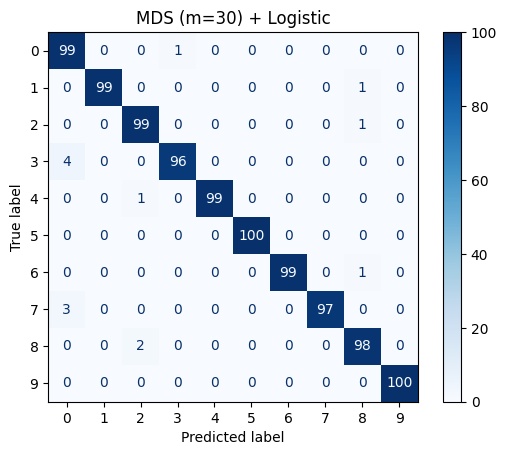

In [ ]:
import pandas as pd
import numpy as np
import os
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.linalg import eigh
from scipy.spatial.distance import cdist 

!unzip -o -q /content/DOMAIN2_CSVcorrigé.zip -d /content/temp_data
print(" Décompression terminée !")

base_path = "/content/temp_data"
contenu = os.listdir(base_path)
if len(contenu) > 0:
    DOMAIN_FOLDER = os.path.join(base_path, contenu[0])

else:
    raise ValueError(" Le dossier temp_data est vide.")

df_list = []
print("---  Début du Chargement (Domain 2) ---")
for subject in range(1, 11):
    for number in range(0, 10):
        for iteration in range(1, 11):
            filename = os.path.join(DOMAIN_FOLDER, f'Subject{subject}-{number}-{iteration}.csv')
            try:
                file = pd.read_csv(filename, skiprows=5, header=None)
                if file.empty or file.shape[0] < 2: continue

                data = file[0].str.strip('"').str.split(',', expand=True)
                file_df = pd.DataFrame(data.iloc[:, :4].values, columns=['x', 'y', 'z', 't'])

                for col in ['x', 'y', 'z', 't']:
                    file_df[col] = pd.to_numeric(file_df[col], errors='coerce')

                file_df.dropna(subset=['x', 'y', 'z', 't'], inplace=True)
                file_df['gesture'] = int(number)
                file_df['subject'] = int(subject)
                file_df['iter'] = int(iteration)
                df_list.append(file_df)
            except:
                continue

df = pd.concat(df_list, ignore_index=True)

def standardize_gesture(df_group):
    df_res = df_group.copy()
    for axis in ['x', 'y', 'z']:
        std = df_res[axis].std()
        df_res[f'{axis}_std'] = (df_res[axis] - df_res[axis].mean()) / std if std != 0 else 0
    return df_res

print(" Standardisation...")
df = df.groupby(['subject', 'gesture', 'iter'], group_keys=False).apply(standardize_gesture)

def resample_gesture(df, target_len=100):
    resampled_data = []
    for (gesture, subject, iteration), group in df.groupby(['gesture', 'subject', 'iter']):
        n = len(group)
        if n < 2: continue
        original_idx = np.arange(n)
        target_idx = np.linspace(0, n - 1, target_len)
        interp = lambda col: interp1d(original_idx, group[col], kind='linear')(target_idx)
        resampled_data.append(pd.DataFrame({
            'gesture': [gesture] * target_len, 'subject': [subject] * target_len, 'iter': [iteration] * target_len,
            'x_std': interp('x_std'), 'y_std': interp('y_std'), 'z_std': interp('z_std')
        }))
    return pd.concat(resampled_data, ignore_index=True)

print(" Resampling à 100 points...")
df100 = resample_gesture(df, target_len=100)


def dtw_dist(seq1, seq2):
    """ VERSION OPTIMISÉE : Utilise cdist pour éviter les boucles Python sur les distances euclidiennes """
    dists = cdist(seq1, seq2, metric='sqeuclidean')

    n, m = dists.shape
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            dtw_matrix[i, j] = dists[i-1, j-1] + min(dtw_matrix[i-1, j],
                                                    dtw_matrix[i, j-1],
                                                    dtw_matrix[i-1, j-1])

    return np.sqrt(dtw_matrix[n, m]) 
def apply_mds_transform(dist_matrix, m=30):
    n = dist_matrix.shape[0]
    D2 = dist_matrix**2
    H = np.eye(n) - np.ones((n, n)) / n
    K = -0.5 * H @ D2 @ H

    vals, vecs = eigh(K, subset_by_index=[n-m, n-1])
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    vals = np.maximum(vals, 0)

    return vecs @ np.diag(np.sqrt(vals))


def run_mds_experiment(df_prep, loop_range=10, m_dims=30):
    all_sequences = []
    all_labels = []
    all_subjects = []

    groups = list(df_prep.groupby(['gesture', 'subject', 'iter']))
    for (g, s, it), group in groups:
        all_sequences.append(group[["x_std", "y_std", "z_std"]].values)
        all_labels.append(g)
        all_subjects.append(s)

    n_total = len(all_sequences)
    print(f"\nCalcul de la matrice de distances DTW ({n_total}x{n_total})...")

    dist_matrix = np.zeros((n_total, n_total))
    for i in range(n_total):
        if i % 50 == 0: print(f"Ligne {i}/{n_total} en cours...")
        for j in range(i + 1, n_total):
            d = dtw_dist(all_sequences[i], all_sequences[j])
            dist_matrix[i, j] = dist_matrix[j, i] = d

    np.save('dist_matrix_backup.npy', dist_matrix)

    print(f" Application du MDS (m={m_dims})...")
    X_features = apply_mds_transform(dist_matrix, m=m_dims)
    y_labels = np.array(all_labels)
    subjects = np.array(all_subjects)

    total_true, total_pred = [], []

    print("\n---  Début des 10 tests (Subject-Out) ---")
    for s_out in range(1, loop_range + 1):
        train_idx = np.where(subjects != s_out)[0]
        test_idx = np.where(subjects == s_out)[0]

        if len(test_idx) == 0: continue

        X_train, X_test = X_features[train_idx], X_features[test_idx]
        y_train, y_test = y_labels[train_idx], y_labels[test_idx]

        clf = LogisticRegression(max_iter=2000, multi_class='ovr')
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)

        acc = accuracy_score(y_test, preds)
        print(f"Précision Sujet {s_out} : {acc:.2%}")

        total_true.extend(y_test)
        total_pred.extend(preds)

    print("\n" + "="*30)
    print(f" PRÉCISION GLOBALE MDS+LOGISTIC : {accuracy_score(total_true, total_pred):.2%}")
    print("="*30)

    cm = confusion_matrix(total_true, total_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues")
    plt.title(f"MDS (m={m_dims}) + Logistic")
    plt.show()

run_mds_experiment(df100, loop_range=10, m_dims=30)